In [64]:
import os
from pathlib import Path
import glob
import re

In [65]:
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession

In [66]:
BASE_DIR = "/volume/data/"

DIRECTORY_SILVER = BASE_DIR+'despesas_contabeis/data/silver/'

In [67]:
spark = SparkSession.builder\
    .appName("data_discovery")\
        .config("spark.driver.memory", "8g") \
            .config("spark.executor.memory", "8g").getOrCreate()


In [68]:
df = spark.read.format('parquet').load(DIRECTORY_SILVER+'tb_dados_contabeis_operadoras')

### Exploratória

In [69]:
#Qtd total de registros

df.count()

10947574

In [70]:
# Avaliar se há duplicadas em relação a conta, reg_ans, e ano_mes_competencia

print(df.columns)
df = df.where(F.col('DATA').isNotNull())

df.groupBy('DATA', 'REG_ANS', 'cd_contabil').count().filter(F.col('count')>1).show(100, truncate=False)



['DATA', 'REG_ANS', 'VL_SALDO_INICIAL', 'VL_SALDO_FINAL', 'year_competencia', 'Registro_ANS', 'Razao_Social', 'Nome_Fantasia', 'Modalidade', 'UF', 'Data_Registro_ANS', 'Data_Descredenciamento', 'Motivo_do_Descredenciamento', 'n1_cd_contabil', 'n1_ds_conta_contabil', 'n2_cd_contabil', 'n2_ds_conta_contabil', 'n3_cd_contabil', 'n3_ds_conta_contabil', 'n4_cd_contabil', 'n4_ds_conta_contabil', 'n5_cd_contabil', 'n5_ds_conta_contabil', 'n6_cd_contabil', 'n6_ds_conta_contabil', 'n8_cd_contabil', 'n8_ds_conta_contabil', 'cd_contabil', 'ds_conta_contabil']
+----+-------+-----------+-----+
|DATA|REG_ANS|cd_contabil|count|
+----+-------+-----------+-----+
+----+-------+-----------+-----+



In [71]:
df.select('n1_cd_contabil', 'n1_ds_conta_contabil').distinct().show()

+--------------+--------------------+
|n1_cd_contabil|n1_ds_conta_contabil|
+--------------+--------------------+
|             1|               ATIVO|
|             3|            RECEITAS|
|             4|            DESPESAS|
|             7|CONTAS TRANSITÓRI...|
|             6|CONTAS DE DESTINA...|
|             2|             PASSIVO|
+--------------+--------------------+



In [72]:
despesas = df.where(F.col('n1_cd_contabil').startswith('4'))
receitas = df.where(F.col('n1_cd_contabil').startswith('3'))

In [73]:
despesas.show(5)

+----------+-------+----------------+--------------+----------------+------------+--------------------+----------------+--------------------+---+-----------------+----------------------+---------------------------+--------------+--------------------+--------------+--------------------+--------------+--------------------+--------------+--------------------+--------------+--------------------+--------------+--------------------+--------------+--------------------+-----------+--------------------+
|      DATA|REG_ANS|VL_SALDO_INICIAL|VL_SALDO_FINAL|year_competencia|Registro_ANS|        Razao_Social|   Nome_Fantasia|          Modalidade| UF|Data_Registro_ANS|Data_Descredenciamento|Motivo_do_Descredenciamento|n1_cd_contabil|n1_ds_conta_contabil|n2_cd_contabil|n2_ds_conta_contabil|n3_cd_contabil|n3_ds_conta_contabil|n4_cd_contabil|n4_ds_conta_contabil|n5_cd_contabil|n5_ds_conta_contabil|n6_cd_contabil|n6_ds_conta_contabil|n8_cd_contabil|n8_ds_conta_contabil|cd_contabil|   ds_conta_contabil|


In [74]:
despesas.select('n2_cd_contabil', 'n2_ds_conta_contabil').distinct().show(100, truncate=False)

+--------------+-------------------------------------------------+
|n2_cd_contabil|n2_ds_conta_contabil                             |
+--------------+-------------------------------------------------+
|46            |DESPESAS ADMINISTRATIVAS                         |
|41            |EVENTOS INDENIZÁVEIS LÍQUIDOS / SINISTROS RETIDOS|
|45            |DESPESAS FINANCEIRAS                             |
|43            |DESPESAS DE COMERCIALIZAÇÃO                      |
|47            |DESPESAS PATRIMONIAIS                            |
|44            |OUTRAS DESPESAS OPERACIONAIS                     |
+--------------+-------------------------------------------------+



In [75]:
despesas.where(F.col('n2_cd_contabil') == '41').groupBy('DATA', 'Registro_ANS', 'Razao_Social', 'Modalidade').agg(F.sum('VL_SALDO_FINAL').alias('sum_vl_saldo_final')).orderBy(['DATA', 'sum_vl_saldo_final'], ascending=[True, False]).show(20, truncate=False)

+----------+------------+-------------------------------------------------------------------------------+---------------------------------+--------------------+
|DATA      |Registro_ANS|Razao_Social                                                                   |Modalidade                       |sum_vl_saldo_final  |
+----------+------------+-------------------------------------------------------------------------------+---------------------------------+--------------------+
|2015-01-01|005711      |BRADESCO SAÚDE S.A.                                                            |Seguradora Especializada em Saúde|3.46912356999E9     |
|2015-01-01|326305      |AMIL ASSISTÊNCIA MÉDICA INTERNACIONAL S.A.                                     |Medicina de Grupo                |2.5780676978799996E9|
|2015-01-01|006246      |SUL AMERICA COMPANHIA DE SEGURO SAÚDE                                          |Seguradora Especializada em Saúde|2.07559275188E9     |
|2015-01-01|393321      |UNIMED-RI

In [76]:
despesas.where(F.col('n2_cd_contabil') == '41').groupBy('DATA', 'Registro_ANS', 'Razao_Social', 'Modalidade').agg(F.sum('VL_SALDO_FINAL').alias('sum_vl_saldo_final')).orderBy(['DATA'], ascending=[True]).show(5, truncate=False)

+----------+------------+-----------------------------------------------------+---------------------------------+------------------+
|DATA      |Registro_ANS|Razao_Social                                         |Modalidade                       |sum_vl_saldo_final|
+----------+------------+-----------------------------------------------------+---------------------------------+------------------+
|2015-01-01|339636      |FUNDAÇÃO DE ASSISTÊNCIA E PREVIDÊNCIA SOCIAL DO BNDES|Autogestão                       |3.003193138E7     |
|2015-01-01|000027      |MASSA FALIDA DE SALUTAR SAÚDE SEGURADORA S.A.        |Seguradora Especializada em Saúde|9535458.92        |
|2015-01-01|302953      |UNIMED DE MACAÉ COOPERATIVA DE ASSISTÊNCIA À SAÚDE   |Cooperativa Médica               |3.492011903E7     |
|2015-01-01|305928      |NOSAMED ASSISTÊNCIA MÉDICA LTDA.                     |Medicina de Grupo                |1423785.9200000002|
|2015-01-01|301396      |SOCIEDADE BENEFICENTE DO HOSPITAL N. S. AUXI

In [77]:
despesas.select(F.min('DATA').alias('min_data'), F.max('DATA').alias('max_data')).show()

df.select(F.min('DATA').alias('min_data'), F.max('DATA').alias('max_data')).show()

+----------+----------+
|  min_data|  max_data|
+----------+----------+
|2015-01-01|2025-01-01|
+----------+----------+

+----------+----------+
|  min_data|  max_data|
+----------+----------+
|2015-01-01|2025-01-01|
+----------+----------+



In [78]:
despesas.count()

4777632

In [79]:
despesas_assistenciais = despesas.where(F.col('n2_cd_contabil') == '41')
despesas_assistenciais.count()

2233647

In [82]:
dfpd = despesas_assistenciais.groupby(F.year('DATA').alias('ano_despesa'), 'Modalidade').agg(F.sum('VL_SALDO_FINAL').alias('sum_vl_saldo_final')).orderBy('sum_vl_saldo_final', ascending=False).toPandas()

<Axes: title={'center': 'Despesas Assistenciais por Ano'}, xlabel='ano_despesa'>

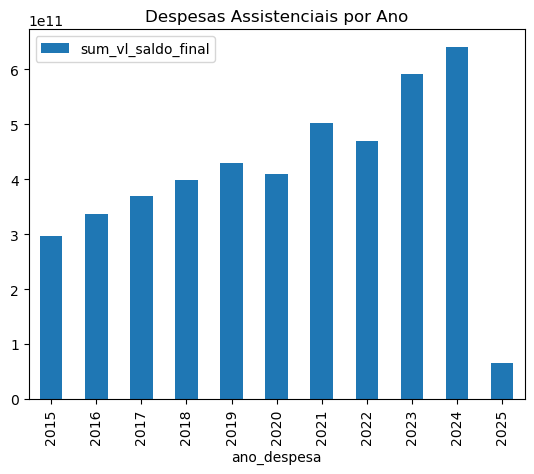

In [84]:
dfpd.groupby('ano_despesa', as_index = False)[['sum_vl_saldo_final']].sum().plot.bar(x='ano_despesa', y='sum_vl_saldo_final', title='Despesas Assistenciais por Ano')